# Summarization of Clinical Expert Knowledge on Neurologic Morbidities
As part of an effort to understand the drivers of clinician suspicion of neuromobidities in the Pediatric ICU (PICU), we asked a group of clinician to draw a Directed Acyclic Graph (DAG). They were able to draw edges of a set of 45 biomarkers that are commonly available in the PICU at UPMC Children's Hospital. These biomarkers include a set of Vitals, Procedures, Diagnostic Tests, Labs, and Drugs.

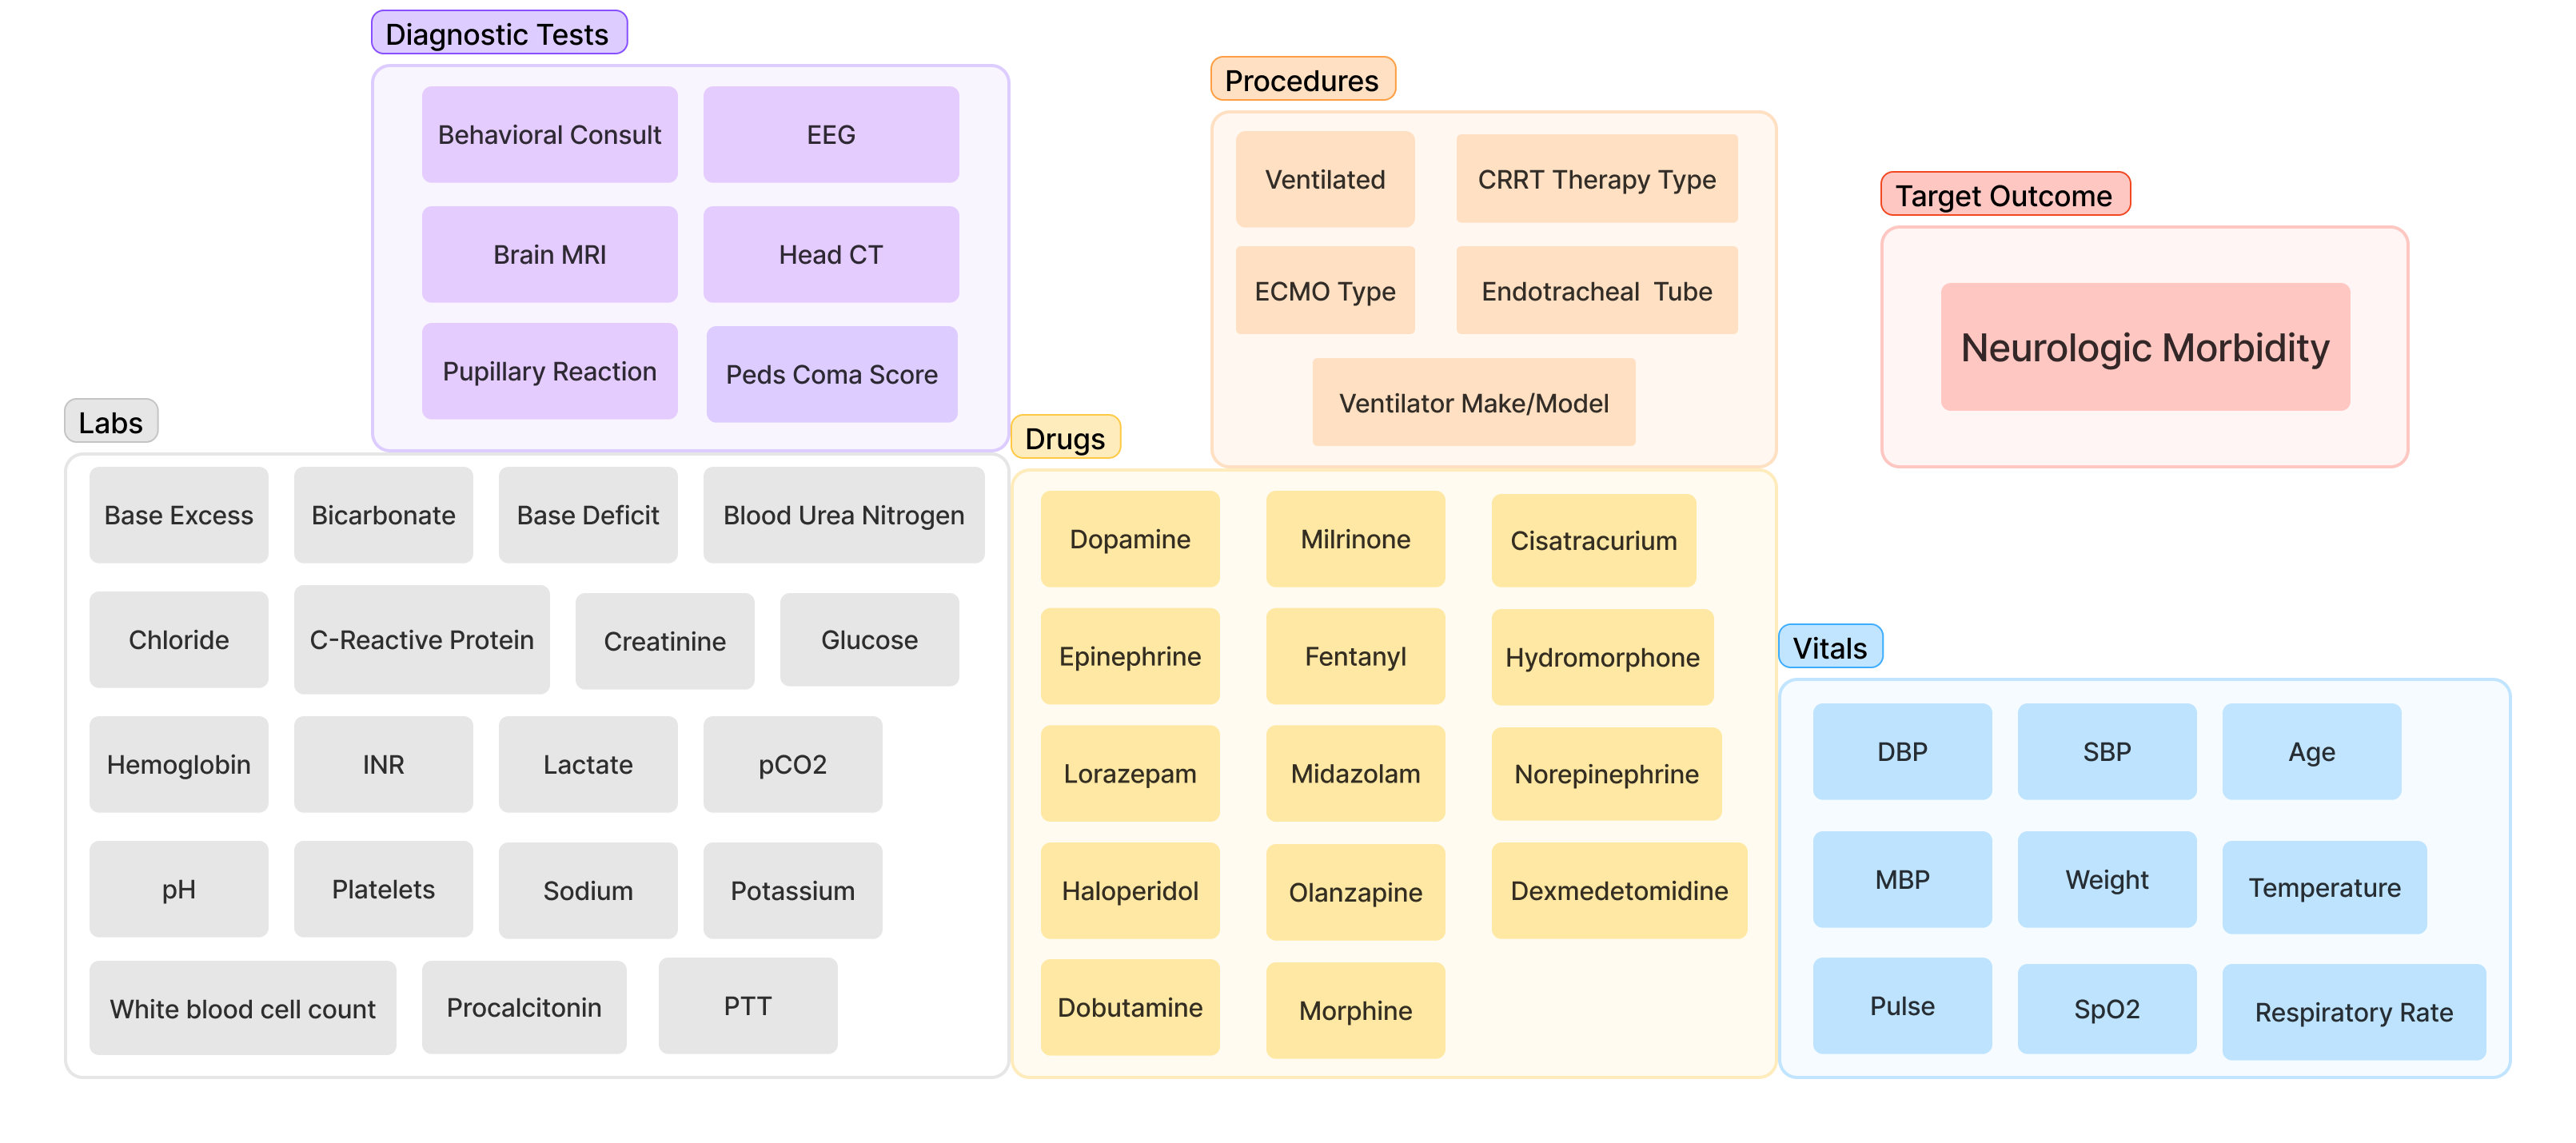

In [1]:
# Libraries
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# Assesign agreement
from statsmodels.stats.inter_rater import cohens_kappa, fleiss_kappa, to_table, aggregate_raters
import krippendorff as kd
import numpy as np

## First Iteration

In [274]:
# Load data
data = (
    pl.scan_csv("/Users/eddie/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Research/Projects/Dissertation/Aim 1/Aim 1.1 Causal Discovery/causal search v2/clinician_dags.csv")
    .unique()
)

df = (
    data
    .group_by('From', 'To')
    .agg(pl.len().alias('weight'))
    .sort('weight', descending=True)
)
df.collect()

From,To,weight
str,str,u32
"""Midazolam""","""Behavioral Consult""",4
"""Peds Coma Score""","""Head CT""",4
"""Peds Coma Score""","""Brain MRI""",3
"""Midazolam""","""Dexmedetomidine""",3
"""Neuromorbidity""","""Head CT""",3
…,…,…
"""Base Excess""","""EEG""",1
"""Morphine""","""Haloperidol""",1
"""Dopamine""","""ECMO""",1


In [119]:
# Get the distribution of the number of edges
top_irr = (df.unique().filter(pl.col('weight') > 1)
 
 )
top_irr.collect()


From,To,weight
str,str,u32
"""Lorazepam""","""EEG""",2
"""Pupillary Reaction""","""Peds Coma Score""",2
"""Neuromorbidity""","""Head CT""",3
"""Lactate""","""Brain MRI""",2
"""Olanzapine""","""Behavioral Consult""",3
…,…,…
"""Hydromorphone""","""Neuromorbidity""",2
"""Sodium""","""Head CT""",2
"""Morphine""","""Neuromorbidity""",2


### Edges were 2/4 clinicians agree

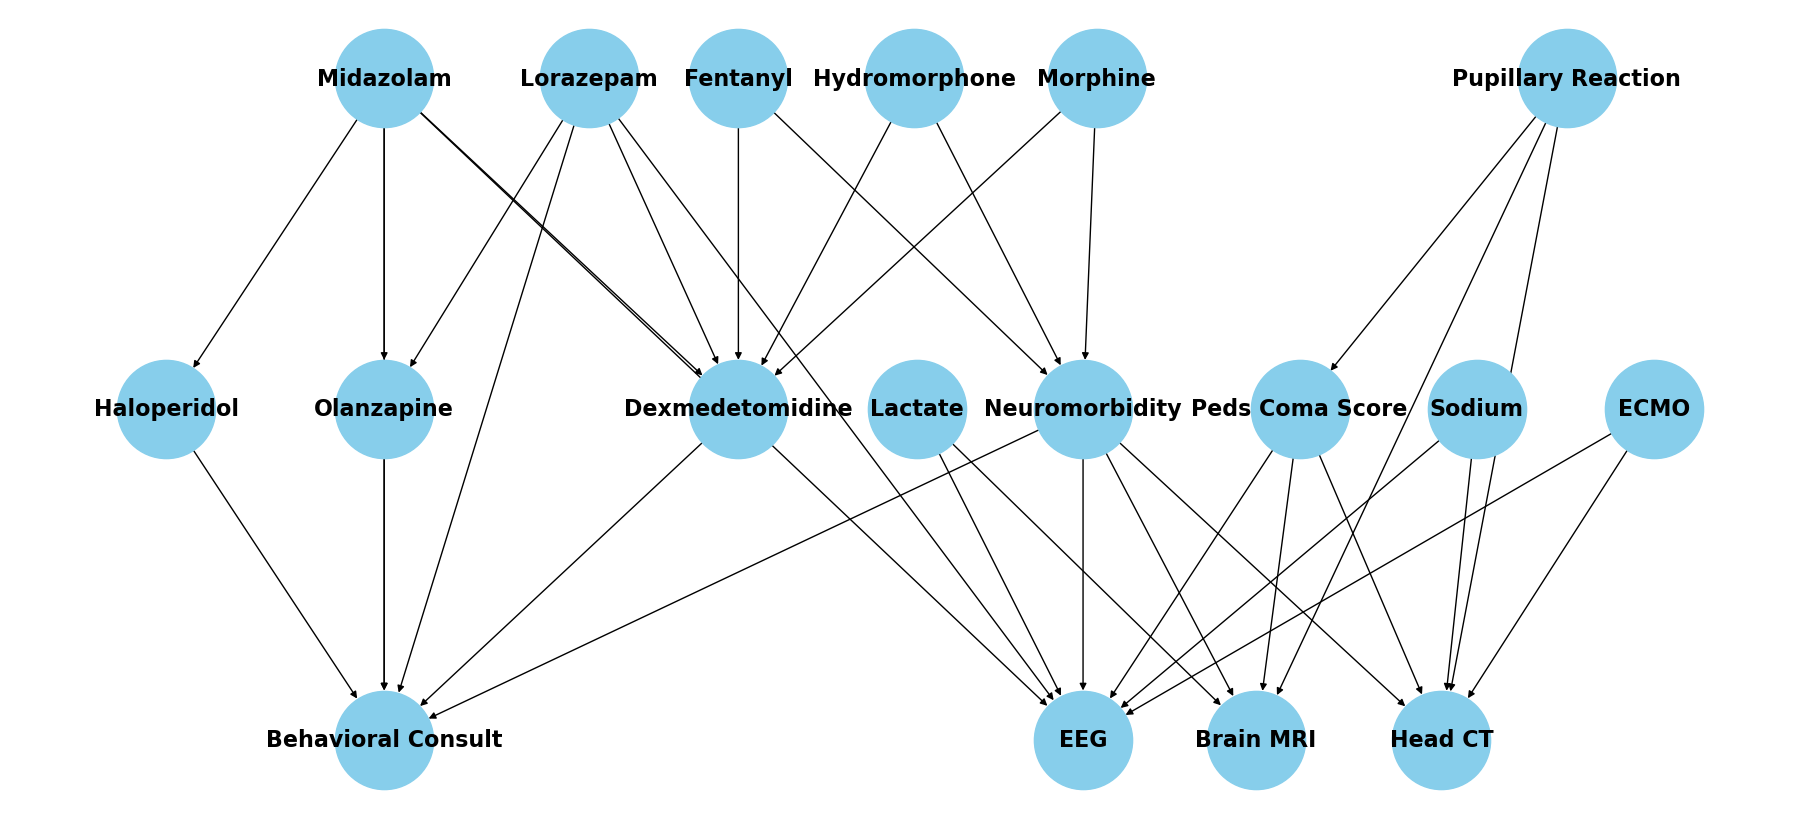

In [34]:
g = df.unique().filter(pl.col('weight') > 1).collect()
G = nx.from_pandas_edgelist(g, source='From', target='To', edge_attr='weight', create_using=nx.DiGraph)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 8))
nx.draw(G, with_labels=True, 
        pos=nx.nx_agraph.graphviz_layout(G, prog='dot'),
        node_size=5000, node_color='skyblue', font_size=16, font_weight='bold'
        )
# nx.draw_networkx_edge_labels(G, 
#                              pos=nx.nx_agraph.graphviz_layout(G, prog='dot'),
#                              edge_labels=nx.get_edge_attributes(G, 'weight'),
#                              font_size=18)
plt.show()

### Graph where 3/4 clinicians agree

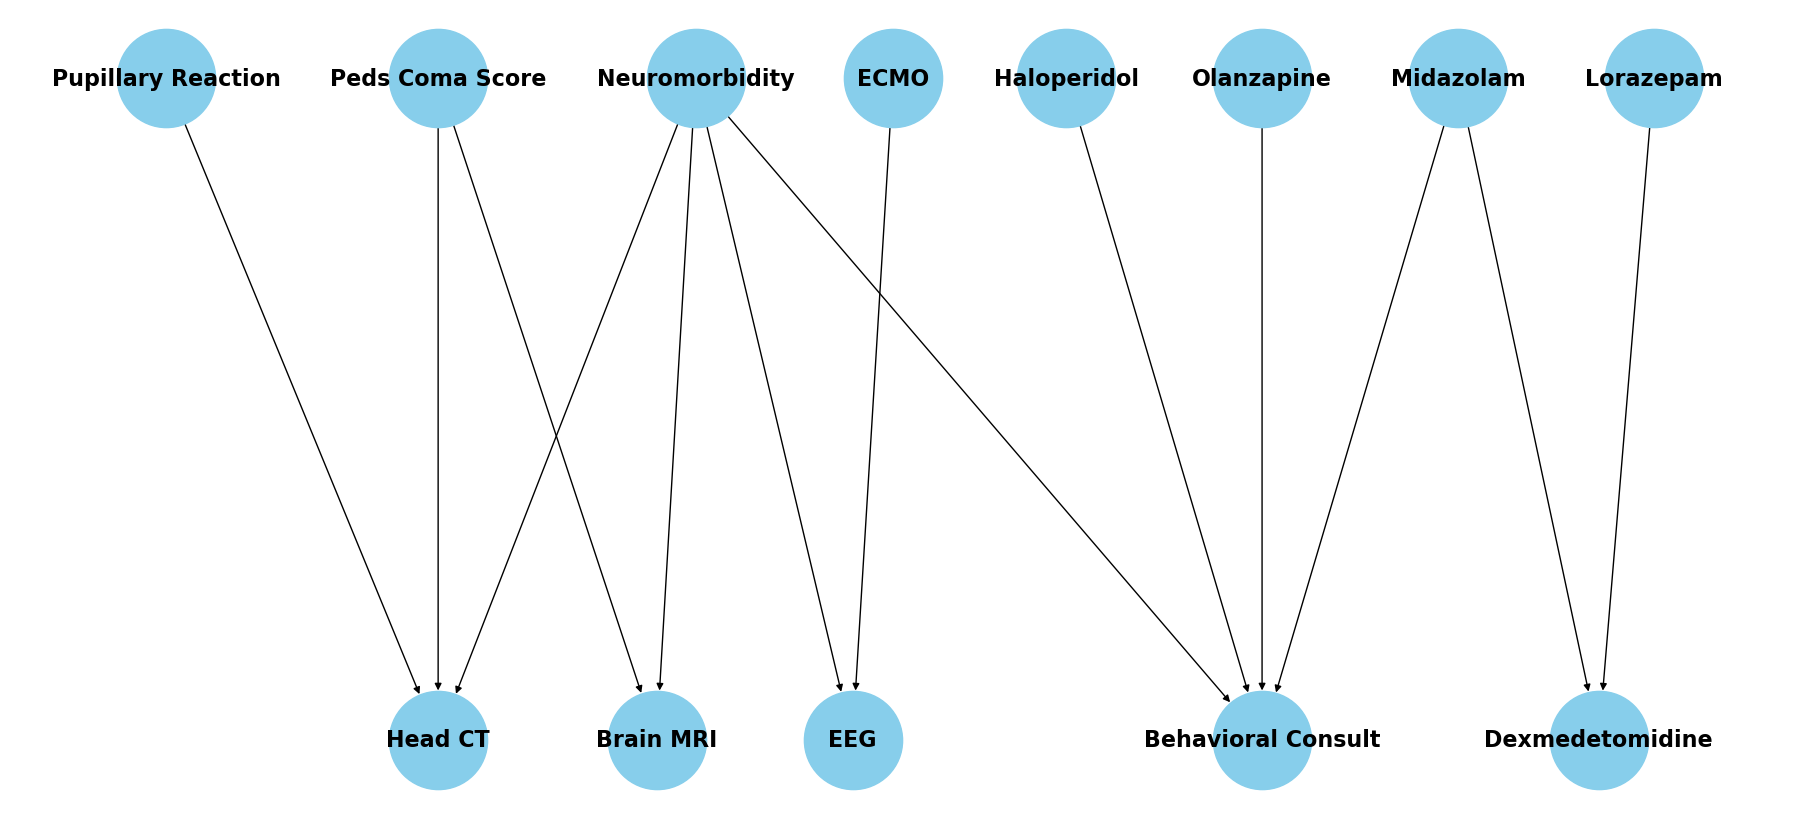

In [35]:
g = df.unique().filter(pl.col('weight') > 2).collect()
G = nx.from_pandas_edgelist(g, source='From', target='To', edge_attr='weight', create_using=nx.DiGraph)

# Plot

plt.figure(figsize=(18, 8))
nx.draw(G, with_labels=True, 
        pos=nx.nx_agraph.graphviz_layout(G, prog='dot'),
        node_size=5000, node_color='skyblue', font_size=16, font_weight='bold'
        )
# nx.draw_networkx_edge_labels(G, 
#                              pos=nx.nx_agraph.graphviz_layout(G, prog='dot'),
#                              edge_labels=nx.get_edge_attributes(G, 'weight'),
#                              font_size=18)
plt.show()

# Agreement

In [285]:
# concatenate the clinician's DAGs
edges = (
    data.with_columns(
            pl.concat_str( [pl.col('From'), pl.col('To')], separator='->').alias('edge')
        )
    # .filter(pl.col('Clinician') !=  2)
    
    .select(['Clinician', 'edge'])
    .with_columns(new_col = 1)
    .collect()
    .pivot(on='edge', index='Clinician', values='new_col')
    .fill_null(0)   
    )

edges


Clinician,Lorazepam->Olanzapine,pH->Behavioral Consult,Sodium->Head CT,pH->Head CT,Peds Coma Score->Brain MRI,Respiratory Rate->ECMO,ECMO->EEG,Midazolam->EEG,Lorazepam->Behavioral Consult,Milrinone->ECMO,Hemoglobin->Head CT,Morphine->Behavioral Consult,Lorazepam->Dexmedetomidine,SBP->Brain MRI,Neuromorbidity->Head CT,Dexmedetomidine->Behavioral Consult,Neuromorbidity->Behavioral Consult,Cisatracurium->EEG,Cisatracurium->Neuromorbidity,Bicarbonate->Behavioral Consult,DBP->Neuromorbidity,Neuromorbidity->Brain MRI,Fentanyl->Behavioral Consult,Peds Coma Score->Head CT,Norepinephrine->ECMO,Ventilated->Haloperidol,Peds Coma Score->EEG,SBP->Head CT,Lorazepam->EEG,Blood Urea Nitrogen->Neuromorbidity,Base Deficit->Head CT,SpO2->ECMO,Base Deficit->Behavioral Consult,Midazolam->Dexmedetomidine,Lorazepam->Neuromorbidity,C-Reactive Protein->EEG,…,SpO2->Neuromorbidity,Pupillary Reaction->Head CT,White Blood Cell Count->Brain MRI,Pulse->EEG,Milrinone->Neuromorbidity,Potassium->Neuromorbidity,Epinephrine->Neuromorbidity,Respiratory Rate->Neuromorbidity,Dopamine->ECMO,Hydromorphone->Behavioral Consult,MBP->Milrinone,Peds Coma Score->Neuromorbidity,Fentanyl->Neuromorbidity,Peds Coma Score->Endotracheal Tube,Lactate->Head CT,Base Deficit->Neuromorbidity,Temperature->Brain MRI,Procalcitonin->EEG,ECMO->Pupillary Reaction,Pulse->ECMO,Age->Dexmedetomidine,CRRT Therapy Type->Neuromorbidity,MBP->Norephinephrine,White Blood Cell Count->EEG,pCO2->ECMO,MBP->Dopamine,Endotracheal Tube->Ventilated,Ventilated->Neuromorbidity,Base Excess->Brain MRI,Age->Neuromorbidity,Dobutamine->Neuromorbidity,Base Excess->Head CT,Epinephrine->ECMO,PTT->INR,Platelets->Head CT,Chloride->Neuromorbidity,Base Excess->EEG
i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
4,1,1,1,1,0,0,1,0,1,0,0,1,1,0,1,0,1,1,0,1,0,1,1,1,0,0,0,0,0,0,1,0,1,1,0,0,…,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1
1,0,0,1,0,1,0,1,1,1,0,1,0,0,1,1,0,1,0,1,0,1,1,0,1,0,0,1,1,1,1,0,0,0,0,0,1,…,1,1,1,1,1,1,1,1,0,0,0,0,1,0,0,1,1,1,0,0,0,1,0,1,0,0,0,1,0,1,1,0,0,1,1,1,0
2,0,0,0,0,1,1,1,0,0,1,0,0,1,0,1,1,1,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,…,0,0,0,0,0,0,0,0,1,0,1,1,1,1,0,0,0,0,0,1,0,0,1,0,1,1,1,0,0,0,0,0,1,0,0,0,0
3,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,1,0,0,0,0,1,0,0,…,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [286]:
raters = edges.drop('Clinician').to_numpy().T
ignored = len(list(combinations(range(53), 2))) - raters.shape[0]
ignored = np.zeros((ignored, raters.shape[1])).astype(int)  # Create an array of zeros for the ignored pairs
raters = np.concatenate([raters, ignored], axis=0)


agg = aggregate_raters(raters, n_cat=2)
print(fleiss_kappa(agg[0], method='fleiss')) # This will compute Fleiss' kappa for the aggregated ratings
print(fleiss_kappa(agg[0], method='randolf'))  # This will compute Randolf's kappa for the aggregated

kd.alpha(raters.T, level_of_measurement='nominal')


0.1945638003734292
0.8889695210449928


np.float64(0.19470992450253333)

## Second Iteration

In [288]:
# Load data
data2 = (
    pl.scan_csv("/Users/eddie/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Research/Projects/Dissertation/Aim 1/Aim 1.1 Causal Discovery/causal search v2/clinician_dags_2.csv")
    .unique()
)

df = (
    data2
    .group_by('From', 'To')
    .agg(pl.len().alias('weight'))
    .sort('weight', descending=True)
)
df.collect()

From,To,weight
str,str,u32
"""Behavioral Consult""","""Haloperidol""",4
"""Behavioral Consult""","""Midazolam""",4
"""Fentanyl""","""Suspicion""",4
"""Haloperidol""","""Diagnosed""",4
"""Midazolam""","""Diagnosed""",4
…,…,…
"""Cisatracurium""","""Fentanyl""",1
"""Temperature""","""Suspicion""",1
"""SBP""","""Suspicion""",1


In [289]:
# Get the distribution of the number of edges
top_irr = (df.unique().filter(pl.col('weight') > 1)
 
 )
top_irr.collect()


From,To,weight
str,str,u32
"""Sodium""","""Suspicion""",2
"""Midazolam""","""Diagnosed""",4
"""Hydromorphone""","""Dexmedetomidine""",3
"""Pulse""","""Suspicion""",2
"""EEG""","""Diagnosed""",3
…,…,…
"""Lorazepam""","""Dexmedetomidine""",3
"""Behavioral Consult""","""Midazolam""",4
"""Hydromorphone""","""Suspicion""",4


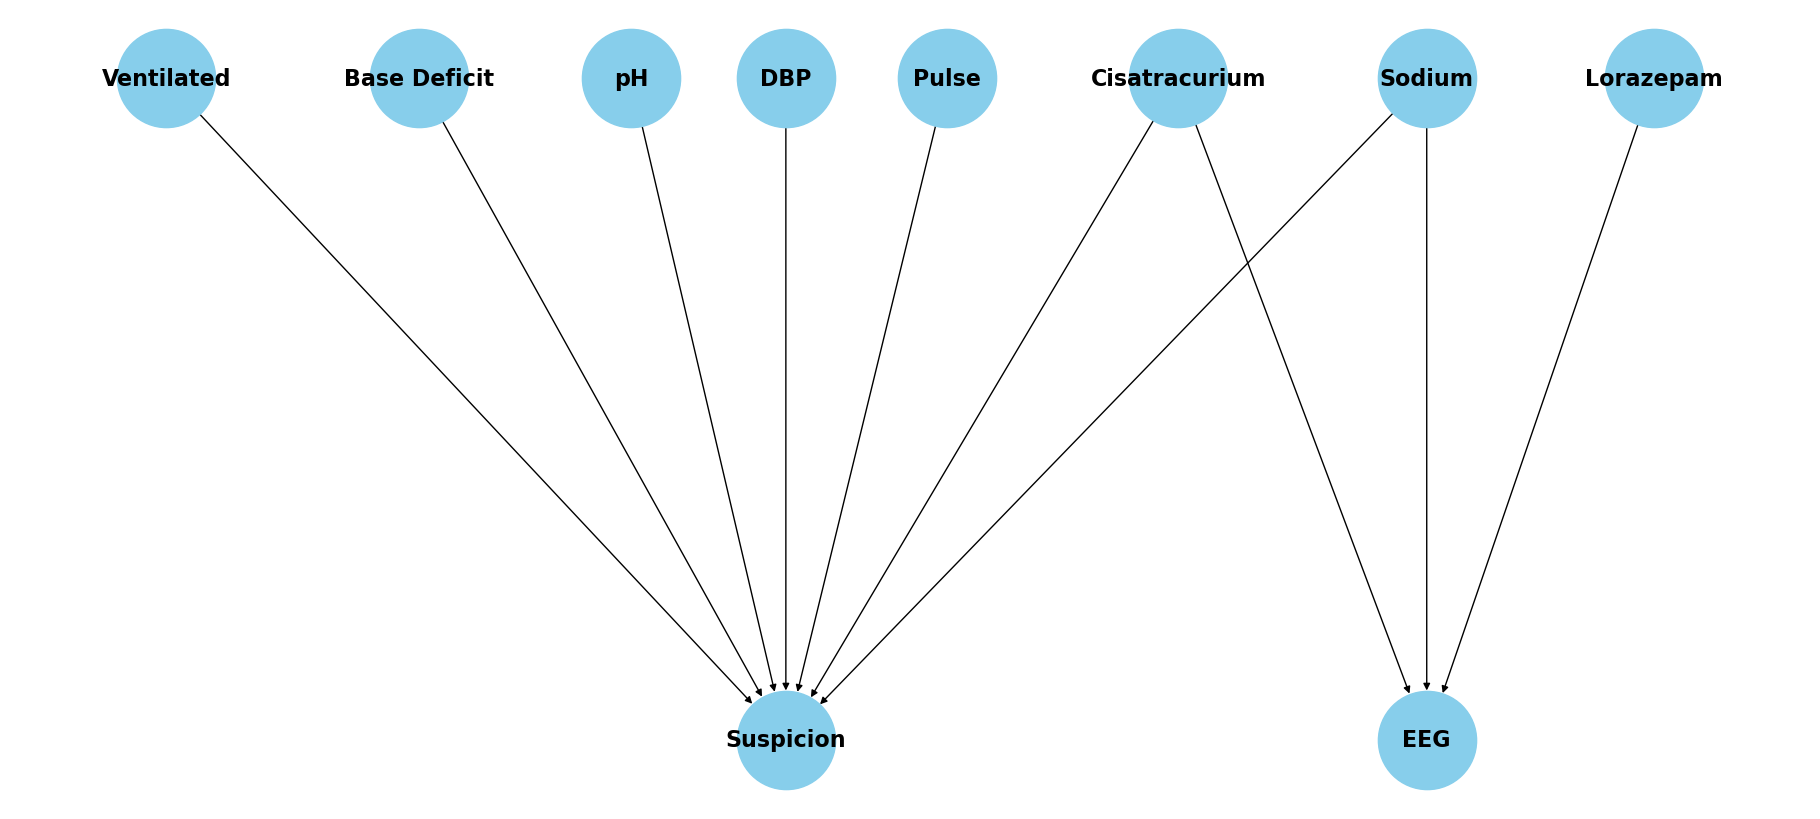

In [293]:
g = df.unique().filter(pl.col('weight') == 2).collect()
G = nx.from_pandas_edgelist(g, source='From', target='To', edge_attr='weight', create_using=nx.DiGraph)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 8))
nx.draw(G, with_labels=True, 
        pos=nx.nx_agraph.graphviz_layout(G, prog='dot'),
        node_size=5000, node_color='skyblue', font_size=16, font_weight='bold'
        )
# nx.draw_networkx_edge_labels(G, 
#                              pos=nx.nx_agraph.graphviz_layout(G, prog='dot'),
#                              edge_labels=nx.get_edge_attributes(G, 'weight'),
#                              font_size=18)
plt.show()

In [295]:
# concatenate the clinician's DAGs
edges = (
    data2.with_columns(
            pl.concat_str( [pl.col('From'), pl.col('To')], separator='->').alias('edge')
        )
    .filter(pl.col('Clinician') != 4)
    
    .select(['Clinician', 'edge'])
    .with_columns(new_col = 1)
    .collect()
    .pivot(on='edge', index='Clinician', values='new_col')
    .fill_null(0)   
    )

edges


Clinician,Cisatracurium->EEG,Brain MRI->Diagnosed,Morphine->Dexmedetomidine,Midazolam->Diagnosed,Olanzapine->Diagnosed,Pulse->Suspicion,Pupillary Reaction->Head CT,Hydromorphone->Dexmedetomidine,Temperature->Suspicion,Suspicion->Head CT,Coma Score->Suspicion,Potassium->Suspicion,Lorazepam->EEG,Hemoglobin->Suspicion,EEG->Diagnosed,Pupillary Reaction->Suspicion,Cisatracurium->Fentanyl,Suspicion->Behavioral Consult,Behavioral Consult->Olanzapine,Hydromorphone->Suspicion,Fentanyl->Dexmedetomidine,Coma Score->Brain MRI,Behavioral Consult->Haloperidol,Fentanyl->Suspicion,Behavioral Consult->Dexmedetomidine,DBP->Suspicion,Sodium->Head CT,ECMO Type->EEG,Morphine->Suspicion,Creatinine->Suspicion,pH->Suspicion,Lorazepam->Dexmedetomidine,Cisatracurium->Suspicion,Dexmedetomidine->Diagnosed,Pupillary Reaction->Coma Score,Suspicion->Brain MRI,Behavioral Consult->Midazolam,Platelets->Suspicion,SpO2->Suspicion,White blood cell count->Suspicion,C-Reactive Protein->Suspicion,Haloperidol->Diagnosed,Cisatracurium->Hydromorphone,Sodium->Suspicion,Coma Score->Head CT,Behavioral Consult->Diagnosed,ECMO Type->Suspicion,Lactate->Brain MRI,Suspicion->EEG,Procalcitonin->Suspicion,Lactate->Suspicion,Head CT->Diagnosed,Base Deficit->Suspicion,Sodium->EEG,INR->Suspicion,Ventilated->Suspicion,Cisatracurium->Morphine,Chloride->Suspicion,Cisatracurium->Olanzapine,CRRT Therapy Type->Suspicion,Midazolam->Lorazepam
i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
3,1,0,1,1,1,0,1,1,0,0,1,0,1,0,0,1,1,0,1,1,1,1,1,1,0,0,1,1,1,0,0,1,0,1,1,0,1,0,0,0,0,1,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,1
1,0,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0,1,1
2,1,1,1,1,1,0,1,1,0,1,1,0,1,0,1,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,0,1,1,0,1,1,1,0,0,0,0,1,0,0,1,1,1,0,1,0,1,1,0,0,0,0,0,0,0,0,1


In [296]:
raters = edges.drop('Clinician').to_numpy().T
ignored = len(list(combinations(range(54), 2))) - raters.shape[0]
ignored = np.zeros((ignored, raters.shape[1])).astype(int)  # Create an array of zeros for the ignored pairs
raters = np.concatenate([raters, ignored], axis=0)


agg = aggregate_raters(raters, n_cat=2)
print(fleiss_kappa(agg[0], method='fleiss')) # This will compute Fleiss' kappa for the aggregated ratings
print(fleiss_kappa(agg[0], method='randolf'))  # This will compute Randolf's kappa for the aggregated


kd.alpha(raters.T, level_of_measurement='nominal') # This will compute Krippendorff's alpha for the aggregated ratings


0.6629253522204294
0.9636617749825298


np.float64(0.6630038694922147)

In [294]:
len(list(combinations(range(54), 2)))

1431

In [1]:
import json
# Set Background Knowledge
bk = {
    # Major Ischemic Event
    'pH' : ['EEG', 'MRI', 'CT', 'Meds', 'BH'],
    'Base Deficit' : ['EEG', 'MRI', 'CT', 'Meds', 'BH'],
    'Ventilated' : ['EEG', 'MRI', 'CT', 'Meds', 'BH'],
    'Pulse' : ['EEG', 'MRI', 'CT', 'Meds', 'BH'],
    'DBP' : ['EEG', 'MRI', 'CT', 'Meds', 'BH'],

    # Drugs
    'Hydromorphone' : ['BH', 'EEG', 'MRI', 'CT', 'Dexmedetomidine'],
    'Lorazepam' : ['EEG', 'Dexmedetomidine'],
    'Midazolam' : ['BH', 'Lorazepam', 'Dexmedetomidine'],
    'Morphine' : ['BH', 'EEG', 'MRI', 'CT', 'Dexmedetomidine'],
    'Fentanyl' : ['BH', 'EEG', 'MRI', 'CT', 'Dexmedetomidine'],
    'Haloperidol' : ['Meds', 'BH'],
    'Olanzapine' : ['Meds', 'BH'],
    'Dexmedetomidine' : ['Meds'],

    # EEG only causes
    'Cisatracurium' : ['EEG'],
    'ECMO Type' : ['EEG'],

    #Head CT only causes
    'Pupillary Reaction' : ['CT'],
    'Peds Coma Score' : ['CT'],

    # Other
    'Sodium' : ['EEG', 'CT'],
    'Lactate' : ['MRI', 'EEG'],

    # Endpoints
    'EEG' : ['Outcome'],
    'CT' : ['Outcome'],
    'MRI' : ['Outcome'],
    'BH' : ['Outcome'],
    'Meds' : ['Outcome']
}

# Save as JSON
with open('/Users/eddie/Library/CloudStorage/OneDrive-UniversityofPittsburgh/Research/Projects/Dissertation/Aim 1/Aim 1.1 Causal Discovery/causal search v2/clinician_dags_bk.json', 'w') as f:
    json.dump(bk, f, indent=4)